In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Joukowski transformation
$$ z = \tau + \frac{k^2}{\tau} $$

## Define circle in $\tau$-plane
Consider a circle of radius $a$ centered at the origin

In [2]:
# define a
a = 1.

# parametrise
phi = np.linspace(0,2*np.pi,100)
xi = a*np.cos(phi)
eta = a*np.sin(phi)

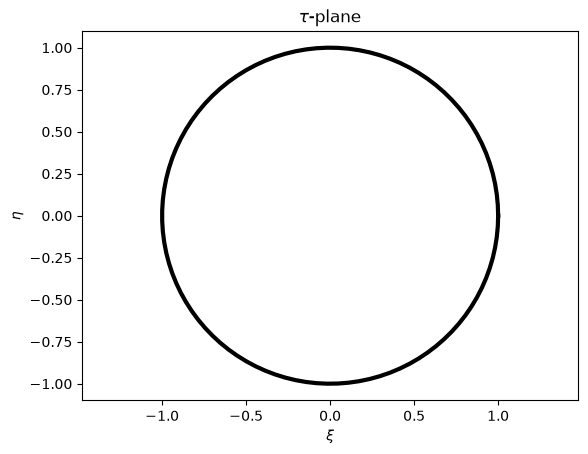

In [3]:
plt.plot(xi,eta,'k',linewidth=3)
plt.xlabel('$\\xi$')
plt.ylabel('$\\eta$')
plt.title('$\\tau$-plane')
plt.axis('equal')
plt.show()

## Map to $z$-plane
Create complex position $\tau$ and then map through Joukowski transformation with chosen $k$

In [6]:
tau = xi + 1j*eta

# Choose k
k = 1.
z = tau + k**2/tau

Plot resulting shape

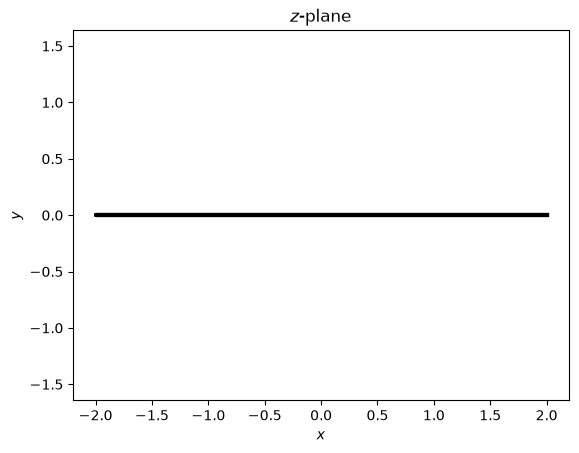

In [7]:
plt.plot(np.real(z),np.imag(z),'k',linewidth=3)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('$z$-plane')
plt.axis('equal')
plt.show()

## Start from $z$-plane ellipse
Define an ellipse with semi-major axis $A$ and semi-minor axis $B$

In [8]:
# define A and B 
A = 3
B = 2

# parametrise 
x = A*np.cos(phi)
y = B*np.sin(phi)

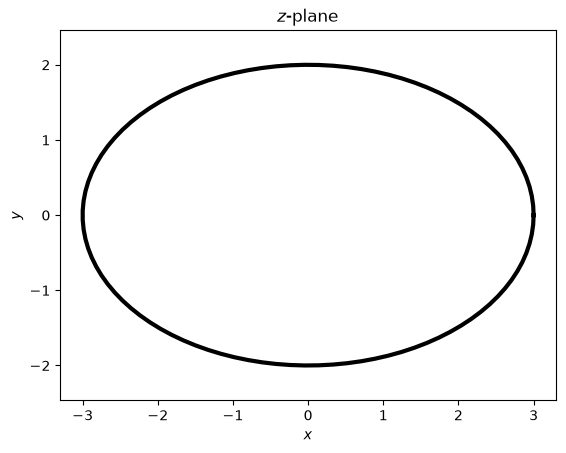

In [9]:
plt.plot(x,y,'k',linewidth=3)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('$z$-plane')
plt.axis('equal')
plt.show()

### Model flow in $\tau$-plane
Define the complex potential for uniform flow around the associated circle and plot streamlines

In [10]:
# create mesh grid in tau-plane
xi = np.linspace(-5,5,100)
eta = np.linspace(-5,5,100)

Xi,Eta = np.meshgrid(xi,eta)

# create meshgrid of complex position
Tau = Xi+1j*Eta

# choose flow speed
c = 1.
    
# complex potential
wtau = c*(Tau+(A+B)**2/(4*Tau))

# extract velocity potential and streamfunction
Phi = np.real(wtau)
Psi = np.imag(wtau)


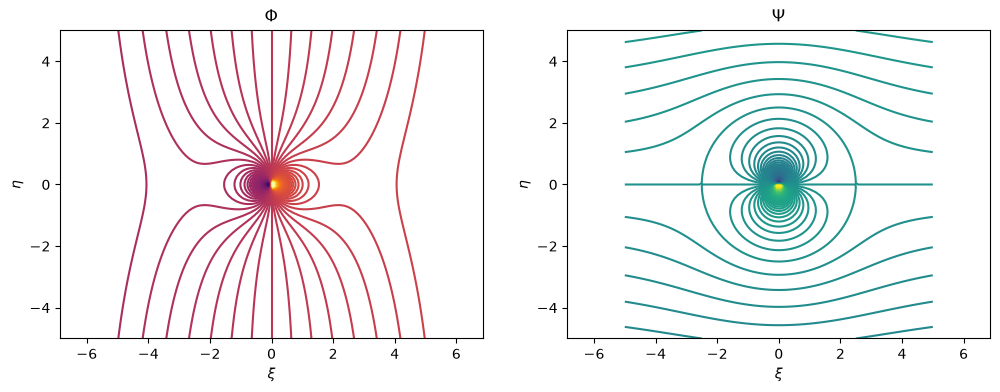

In [11]:
fig = plt.figure(figsize=(12,4))
ax1, ax2 = fig.subplots(1, 2)

ax1.contour(Xi,Eta,Phi,200,cmap='inferno')
ax1.set_xlabel('$\\xi$')
ax1.set_ylabel('$\\eta$')
ax1.set_title('$\\Phi$')
ax1.axis('equal')

ax2.contour(Xi,Eta,Psi,200)
ax2.set_xlabel('$\\xi$')
ax2.set_ylabel('$\\eta$')
ax2.set_title('$\\Psi$')
ax2.axis('equal')

plt.show()

### Model flow in $z$-plane
Define the complex potential as derived in class and plot streamlines

In [12]:
# create mesh grid in z-plane
x = np.linspace(-5,5,100)
y = np.linspace(-5,5,100)

X,Y = np.meshgrid(x,y)

# create meshgrid of complex position
Z = X+1j*Y

# choose flow speed
c = 1.
    
# complex potential using positive branch
wz_plus = c*((Z+np.sqrt(Z**2-(A**2-B**2)))/2+(A+B)**2/(2*(Z+np.sqrt(Z**2-(A**2-B**2)))))

# extract velocity potential and streamfunction
Phi_z = np.real(wz_plus)
Psi_z = np.imag(wz_plus)


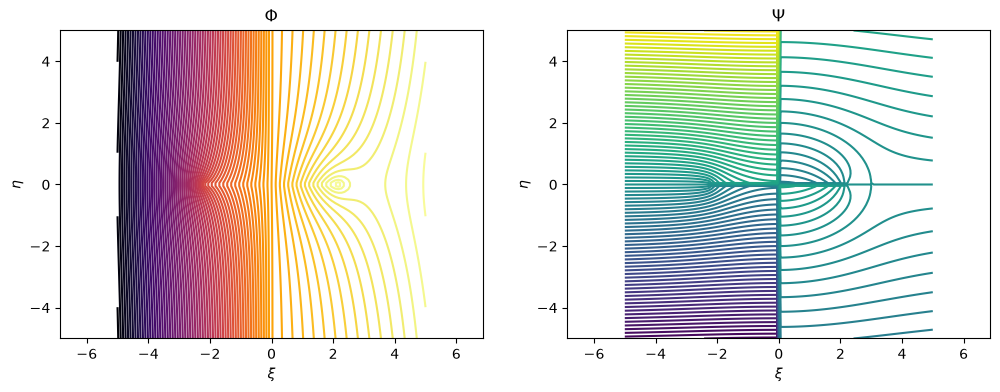

In [13]:
fig = plt.figure(figsize=(12,4))
ax1, ax2 = fig.subplots(1, 2)

ax1.contour(X,Y,Phi_z,100,cmap='inferno')
ax1.set_xlabel('$\\xi$')
ax1.set_ylabel('$\\eta$')
ax1.set_title('$\\Phi$')
ax1.axis('equal')

ax2.contour(X,Y,Psi_z,100)
ax2.set_xlabel('$\\xi$')
ax2.set_ylabel('$\\eta$')
ax2.set_title('$\\Psi$')
ax2.axis('equal')

plt.show()

From observation this complex potential applies when $\Re(z)>0$

In [14]:
# calculate minus branch
wz_minus = c*((Z-np.sqrt(Z**2-(A**2-B**2)))/2+(A+B)**2/(2*(Z-np.sqrt(Z**2-(A**2-B**2)))))

# extract velocity potential and streamfunction
Phi_z = np.real(wz_minus)
Psi_z = np.imag(wz_minus)

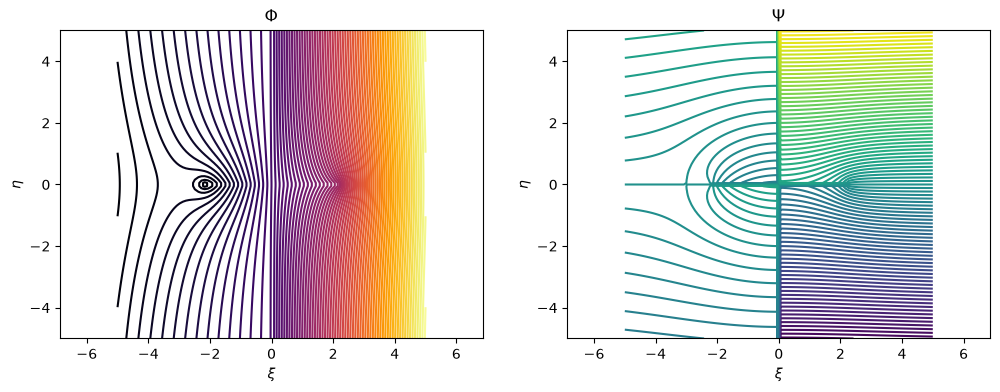

In [15]:
fig = plt.figure(figsize=(12,4))
ax1, ax2 = fig.subplots(1, 2)

ax1.contour(X,Y,Phi_z,100,cmap='inferno')
ax1.set_xlabel('$\\xi$')
ax1.set_ylabel('$\\eta$')
ax1.set_title('$\\Phi$')
ax1.axis('equal')

ax2.contour(X,Y,Psi_z,100)
ax2.set_xlabel('$\\xi$')
ax2.set_ylabel('$\\eta$')
ax2.set_title('$\\Psi$')
ax2.axis('equal')

plt.show()

Similarly, this complex potential applies when $\Re(z)<0$

Let's combine into one potential

In [16]:
# combine branches
wz = (np.real(Z) >= 0 )*wz_plus + (np.real(Z) < 0 )*wz_minus

# extract velocity potential and streamfunction
Phi_z = np.real(wz)
Psi_z = np.imag(wz)

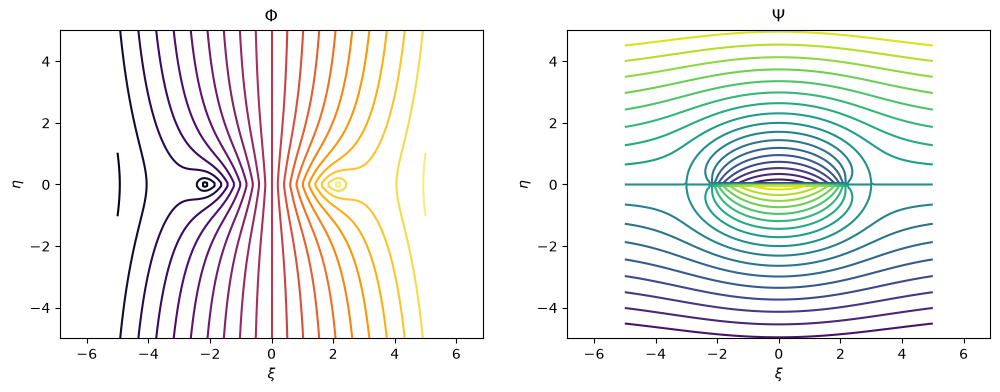

In [17]:
fig = plt.figure(figsize=(12,4))
ax1, ax2 = fig.subplots(1, 2)

ax1.contour(X,Y,Phi_z,20,cmap='inferno')
ax1.set_xlabel('$\\xi$')
ax1.set_ylabel('$\\eta$')
ax1.set_title('$\\Phi$')
ax1.axis('equal')

ax2.contour(X,Y,Psi_z,20)
ax2.set_xlabel('$\\xi$')
ax2.set_ylabel('$\\eta$')
ax2.set_title('$\\Psi$')
ax2.axis('equal')

plt.show()

### Compare flow in $z$-plane when directly using Joukowski map
Use complex potential $w(\tau)$ projected onto $z$-plane

In [19]:
k2 = (A**2-B**2)/4

# convert back to x and y
Z_proj = Tau + k2/Tau
X_proj = np.real(Z_proj)
Y_proj = np.imag(Z_proj)

# mask out interior
wtau_masked = np.ma.masked_where(np.absolute(Tau)<(A+B)/2, wtau)
Phi_masked = np.real(wtau_masked)
Psi_masked = np.imag(wtau_masked)

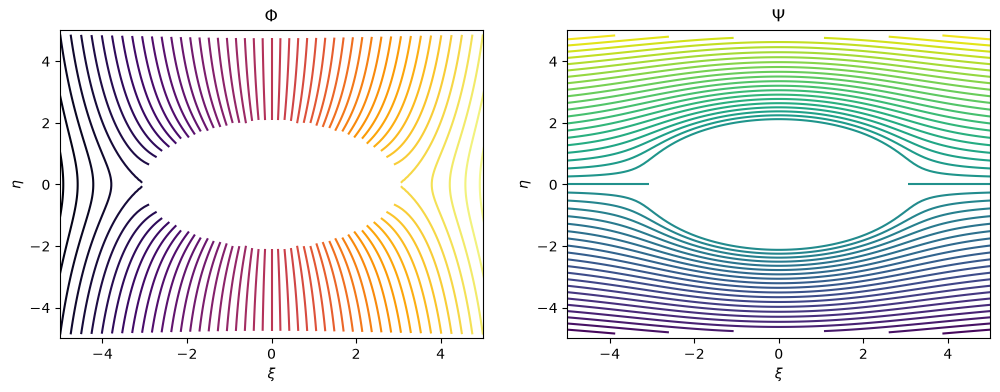

In [22]:
fig = plt.figure(figsize=(12,4))
ax1, ax2 = fig.subplots(1, 2)

ax1.contour(X_proj,Y_proj,Phi_masked,50,cmap='inferno')
ax1.set_xlabel('$\\xi$')
ax1.set_ylabel('$\\eta$')
ax1.set_title('$\\Phi$')
ax1.axis([-5,5,-5,5])

ax2.contour(X_proj,Y_proj,Psi_masked,50)
ax2.set_xlabel('$\\xi$')
ax2.set_ylabel('$\\eta$')
ax2.set_title('$\\Psi$')
ax2.axis([-5,5,-5,5])

plt.show()